### Salary prediction, episode II: make it actually work (4 points)

Your main task is to use some of the tricks you've learned on the network and analyze if you can improve __validation MAE__. Try __at least 3 options__ from the list below for a passing grade. Write a short report about what you have tried. More ideas = more bonus points.

__Please be serious:__ " plot learning curves in MAE/epoch, compare models based on optimal performance, test one change at a time. You know the drill :)

You can use either __pytorch__ or __tensorflow__ or any other framework (e.g. pure __keras__). Feel free to adapt the seminar code for your needs. For tensorflow version, consider `seminar_tf2.ipynb` as a starting point.


In [ ]:
# < A whole lot of your code > - models, charts, analysis

### A short report

Please tell us what you did and how did it work.

`<YOUR_TEXT_HERE>`, i guess...

## Recommended options

#### A) CNN architecture

All the tricks you know about dense and convolutional neural networks apply here as well.
* Dropout. Nuff said.
* Batch Norm. This time it's `nn.BatchNorm*`/`L.BatchNormalization`
* Parallel convolution layers. The idea is that you apply several nn.Conv1d to the same embeddings and concatenate output channels.
* More layers, more neurons, ya know...


#### B) Play with pooling

There's more than one way to perform pooling:
* Max over time (independently for each feature)
* Average over time (excluding PAD)
* Softmax-pooling:
$$ out_{i, t} = \sum_t {h_{i,t} \cdot {{e ^ {h_{i, t}}} \over \sum_\tau e ^ {h_{j, \tau}} } }$$

* Attentive pooling
$$ out_{i, t} = \sum_t {h_{i,t} \cdot Attn(h_t)}$$

, where $$ Attn(h_t) = {{e ^ {NN_{attn}(h_t)}} \over \sum_\tau e ^ {NN_{attn}(h_\tau)}}  $$
and $NN_{attn}$ is a dense layer.

The optimal score is usually achieved by concatenating several different poolings, including several attentive pooling with different $NN_{attn}$ (aka multi-headed attention).

The catch is that keras layers do not inlude those toys. You will have to [write your own keras layer](https://keras.io/layers/writing-your-own-keras-layers/). Or use pure tensorflow, it might even be easier :)

#### C) Fun with words

It's not always a good idea to train embeddings from scratch. Here's a few tricks:

* Use a pre-trained embeddings from `gensim.downloader.load`. See last lecture.
* Start with pre-trained embeddings, then fine-tune them with gradient descent. You may or may not download pre-trained embeddings from [here](http://nlp.stanford.edu/data/glove.6B.zip) and follow this [manual](https://keras.io/examples/nlp/pretrained_word_embeddings/) to initialize your Keras embedding layer with downloaded weights.
* Use the same embedding matrix in title and desc vectorizer


#### D) Going recurrent

We've already learned that recurrent networks can do cool stuff in sequence modelling. Turns out, they're not useless for classification as well. With some tricks of course..

* Like convolutional layers, LSTM should be pooled into a fixed-size vector with some of the poolings.
* Since you know all the text in advance, use bidirectional RNN
  * Run one LSTM from left to right
  * Run another in parallel from right to left
  * Concatenate their output sequences along unit axis (dim=-1)

* It might be good idea to mix convolutions and recurrent layers differently for title and description


#### E) Optimizing seriously

* You don't necessarily need 100 epochs. Use early stopping. If you've never done this before, take a look at [early stopping callback(keras)](https://keras.io/callbacks/#earlystopping) or in [pytorch(lightning)](https://pytorch-lightning.readthedocs.io/en/latest/common/early_stopping.html).
  * In short, train until you notice that validation
  * Maintain the best-on-validation snapshot via `model.save(file_name)`
  * Plotting learning curves is usually a good idea
  
Good luck! And may the force be with you!

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data = pd.read_csv("/content/drive/MyDrive/nlp_course/Train_rev1.zip", compression='zip', index_col=None)
data.shape

(244768, 12)

In [4]:
data['Log1pSalary'] = np.log1p(data['SalaryNormalized']).astype('float32')


In [5]:
text_columns = ["Title", "FullDescription"]
categorical_columns = ["Category", "Company", "LocationNormalized", "ContractType", "ContractTime"]
TARGET_COLUMN = "Log1pSalary"

data[categorical_columns] = data[categorical_columns].fillna('NaN') # cast missing values to string "NaN"

data.sample(3)

,Id,Title,FullDescription,LocationRaw,LocationNormalized,ContractType,ContractTime,Company,Category,SalaryRaw,SalaryNormalized,SourceName,Log1pSalary
97177,69258792,Sales Manager / Sales Team Leader,Job Title Sales Manager / Sales Team Leader / ...,Chester,Chester,full_time,NaN,BMS Recruitment,Sales Jobs,30000,30000,careerbuilder.com,10.308986
160423,71185766,Research and Marketing Director B2B,My client is a management consultancy business...,London South East,South East London,NaN,permanent,Burnett Hall,"PR, Advertising & Marketing Jobs","From 90,000 to 100,000 per annum + bonus + ben...",95000,totaljobs.com,11.461642
182910,71619306,General Manager Age UK Hampshire/Isle of Wight,Age UK Hampshire and IoW Trading Ltd is a new ...,"Isle of Wight, South East",Isle Of Wight,NaN,permanent,NaN,Other/General Jobs,30-35K pa depending on experience,32500,jobs.telegraph.co.uk,10.389026


In [6]:
import nltk
#TODO YOUR CODE HERE

tokenizer = nltk.tokenize.WordPunctTokenizer()

def tokenize_to_str(text: str) -> str:
    text = str(text).lower()
    return " ".join(tokenizer.tokenize(text))

for col in ["Title", "FullDescription"]:
  data[col] = data[col].apply(tokenize_to_str)

In [7]:
from collections import Counter
token_counts = Counter()

# Count how many times does each token occur in both "Title" and "FullDescription" in total
#TODO <YOUR CODE>
for col in ["Title", "FullDescription"]:
    for text in data[col].values:
        token_counts.update(text.split())

In [8]:
min_count = 10

# tokens from token_counts keys that had at least min_count occurrences throughout the dataset
tokens = [t for t, cnt in token_counts.items() if cnt >= min_count]

# Add a special tokens for unknown and empty words
UNK, PAD = "UNK", "PAD"
tokens = [UNK, PAD] + tokens

In [9]:
token_to_id = {token: i for i, token in enumerate(tokens)} #<your code here - dict of token name to its index in tokens>

In [10]:
UNK_IX, PAD_IX = map(token_to_id.get, [UNK, PAD])

def as_matrix(sequences, max_len=None):
    """ Convert a list of tokens into a matrix with padding """
    if isinstance(sequences[0], str):
        sequences = list(map(str.split, sequences))

    max_len = min(max(map(len, sequences)), max_len or float('inf'))

    matrix = np.full((len(sequences), max_len), np.int32(PAD_IX))
    for i,seq in enumerate(sequences):
        row_ix = [token_to_id.get(word, UNK_IX) for word in seq[:max_len]]
        matrix[i, :len(row_ix)] = row_ix

    return matrix

In [11]:
from sklearn.feature_extraction import DictVectorizer

# we only consider top-1k most frequent companies to minimize memory usage
top_companies, top_counts = zip(*Counter(data['Company']).most_common(1000))
recognized_companies = set(top_companies)
data["Company"] = data["Company"].apply(lambda comp: comp if comp in recognized_companies else "Other")

categorical_vectorizer = DictVectorizer(dtype=np.float32, sparse=False)
categorical_vectorizer.fit(data[categorical_columns].apply(dict, axis=1))

DictVectorizer(dtype=<class 'numpy.float32'>, sparse=False)

In [12]:
from sklearn.model_selection import train_test_split

data_train, data_val = train_test_split(data, test_size=0.2, random_state=42)
data_train.index = range(len(data_train))
data_val.index = range(len(data_val))

print("Train size = ", len(data_train))
print("Validation size = ", len(data_val))

Train size =  195814
Validation size =  48954


In [14]:
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from tqdm.auto import tqdm
import torch.nn.functional as F
%config InlineBackend.figure_format = 'retina'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [15]:
def to_tensors(batch, device):
    batch_tensors = dict()
    for key, arr in batch.items():
        if key in ["FullDescription", "Title"]:
            batch_tensors[key] = torch.tensor(arr, device=device, dtype=torch.int64)
        else:
            batch_tensors[key] = torch.tensor(arr, device=device)
    return batch_tensors


def make_batch(data, max_len=None, word_dropout=0, device=device):
    """
    Creates a keras-friendly dict from the batch data.
    :param word_dropout: replaces token index with UNK_IX with this probability
    :returns: a dict with {'title' : int64[batch, title_max_len]
    """
    batch = {}
    batch["Title"] = as_matrix(data["Title"].values, max_len)
    batch["FullDescription"] = as_matrix(data["FullDescription"].values, max_len)
    batch['Categorical'] = categorical_vectorizer.transform(data[categorical_columns].apply(dict, axis=1))

    if word_dropout != 0:
        batch["FullDescription"] = apply_word_dropout(batch["FullDescription"], 1. - word_dropout)

    if TARGET_COLUMN in data.columns:
        batch[TARGET_COLUMN] = data[TARGET_COLUMN].values

    return to_tensors(batch, device)

def apply_word_dropout(matrix, keep_prop, replace_with=UNK_IX, pad_ix=PAD_IX,):
    dropout_mask = np.random.choice(2, np.shape(matrix), p=[keep_prop, 1 - keep_prop])
    dropout_mask &= matrix != pad_ix
    return np.choose(dropout_mask, [matrix, np.full_like(matrix, replace_with)])

In [16]:


def iterate_minibatches(data, batch_size=256, shuffle=True, cycle=False, device=device, **kwargs):
    """Iterate minibatches of pandas DataFrame -> dict of torch tensors (via make_batch)."""
    while True:
        indices = np.arange(len(data))
        if shuffle:
            indices = np.random.permutation(indices)
        for start in range(0, len(indices), batch_size):
            batch = make_batch(data.iloc[indices[start:start+batch_size]], device=device, **kwargs)
            yield batch
        if not cycle:
            break

@torch.no_grad()
def eval_mae(model, data, batch_size=256, device=device, **kw):
    model.eval()
    abs_error = num_samples = 0.0
    for batch in iterate_minibatches(data, batch_size=batch_size, shuffle=False, device=device, **kw):
        pred = model(batch)
        abs_error += torch.sum(torch.abs(pred - batch[TARGET_COLUMN]))
        num_samples += len(pred)
    return (abs_error / num_samples).detach().cpu().item()


In [ ]:


def fit_model(
    model,
    train_df,
    val_df,
    *,
    lr=1e-3,
    batch_size=128,
    max_epochs=10,
    steps_per_epoch=None,
    grad_clip=None,
    live_plot=True,
    verbose=True,
):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    if steps_per_epoch is None:
        steps_per_epoch = int(np.ceil(len(train_df) / batch_size))

    history = {"train_mse": [], "val_mae": []}

    train_iter = iterate_minibatches(
        train_df, batch_size=batch_size, shuffle=True, cycle=True, device=device
    )

    for epoch in range(1, max_epochs + 1):
        model.train()
        running_mse = 0.0

        for _ in tqdm(range(steps_per_epoch), desc=f"epoch {epoch}", leave=False):
            batch = next(train_iter)
            pred = model(batch)
            loss = criterion(pred, batch[TARGET_COLUMN])

            opt.zero_grad(set_to_none=True)
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

            running_mse += loss.detach().cpu().item()

        train_mse = running_mse / steps_per_epoch
        val_mae = eval_mae(model, val_df, batch_size=batch_size, device=device)

        history["train_mse"].append(train_mse)
        history["val_mae"].append(val_mae)

        if verbose:
            print(f"Epoch {epoch:03d} | train MSE {train_mse:.5f} | val MAE {val_mae:.5f}")

        if live_plot:
            clear_output(wait=True)
            epochs = np.arange(1, len(history["val_mae"]) + 1)

            fig, ax = plt.subplots(figsize=(8, 4))
            ax.plot(epochs, history["val_mae"], marker="o")
            ax.set_xlabel("epoch")
            ax.set_ylabel("val MAE")
            ax.grid(True)
            ax.set_title("Validation MAE (online)")
            display(fig)
            plt.close(fig)

    return model, history


In [17]:
from IPython.display import clear_output, display
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from tqdm.auto import tqdm

@torch.no_grad()
def eval_mae(model, data, batch_size=256, device=device, **kw):
    model.eval()
    abs_error = 0.0
    num_samples = 0.0
    for batch in iterate_minibatches(data, batch_size=batch_size, shuffle=False, device=device, **kw):
        pred = model(batch)
        abs_error += torch.sum(torch.abs(pred - batch[TARGET_COLUMN]))
        num_samples += len(pred)
    return (abs_error / num_samples).detach().cpu().item()

def fit_model(
    model,
    train_df,
    val_df,
    *,
    lr=1e-3,
    batch_size=128,
    max_epochs=10,
    steps_per_epoch=None,
    grad_clip=None,
    log_every=100,
    live_plot=True,
    eval_train_every_epoch=True,
    eval_batch_size=256,
    verbose=True,
):
    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    if steps_per_epoch is None:
        steps_per_epoch = int(np.ceil(len(train_df) / batch_size))

    history = {
        "steps": [],
        "train_mse_steps": [],     # train loss (окно) по шагам
        "epochs": [],
        "train_mae": [],           # train metric по эпохам
        "val_mae": [],             # val metric по эпохам
    }

    train_iter = iterate_minibatches(
        train_df, batch_size=batch_size, shuffle=True, cycle=True, device=device
    )

    global_step = 0
    recent_losses = []

    for epoch in range(1, max_epochs + 1):
        model.train()

        for _ in tqdm(range(steps_per_epoch), desc=f"epoch {epoch}", leave=False):
            batch = next(train_iter)
            pred = model(batch)
            loss = criterion(pred, batch[TARGET_COLUMN])

            opt.zero_grad(set_to_none=True)
            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            opt.step()

            recent_losses.append(loss.detach().cpu().item())
            global_step += 1

            if live_plot and (global_step % log_every == 0):
                # log window-avg train MSE
                history["steps"].append(global_step)
                history["train_mse_steps"].append(float(np.mean(recent_losses)))
                recent_losses.clear()

                clear_output(wait=True)
                fig, ax = plt.subplots(figsize=(8, 4))
                ax.plot(history["steps"], history["train_mse_steps"], marker=".")
                ax.set_xlabel("training step")
                ax.set_ylabel("train MSE (avg over last window)")
                ax.set_title("Training loss (online)")
                ax.grid(True)
                display(fig)
                plt.close(fig)

        train_mae = eval_mae(model, train_df, batch_size=eval_batch_size, device=device) if eval_train_every_epoch else None
        val_mae = eval_mae(model, val_df, batch_size=eval_batch_size, device=device)

        history["epochs"].append(epoch)
        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)

        if verbose:
            if train_mae is not None:
                print(f"Epoch {epoch:03d} | train MAE {train_mae:.5f} | val MAE {val_mae:.5f}")
            else:
                print(f"Epoch {epoch:03d} | val MAE {val_mae:.5f}")

    return model, history

def plot_history(history):
    epochs = history["epochs"]
    plt.figure(figsize=(8, 4))
    if all(v is not None for v in history["train_mae"]):
        plt.plot(epochs, history["train_mae"], marker="o", label="train MAE")
    plt.plot(epochs, history["val_mae"], marker="o", label="val MAE")
    plt.xlabel("epoch")
    plt.ylabel("MAE")
    plt.title("Train/Val MAE by epoch")
    plt.grid(True)
    plt.legend()
    plt.show()


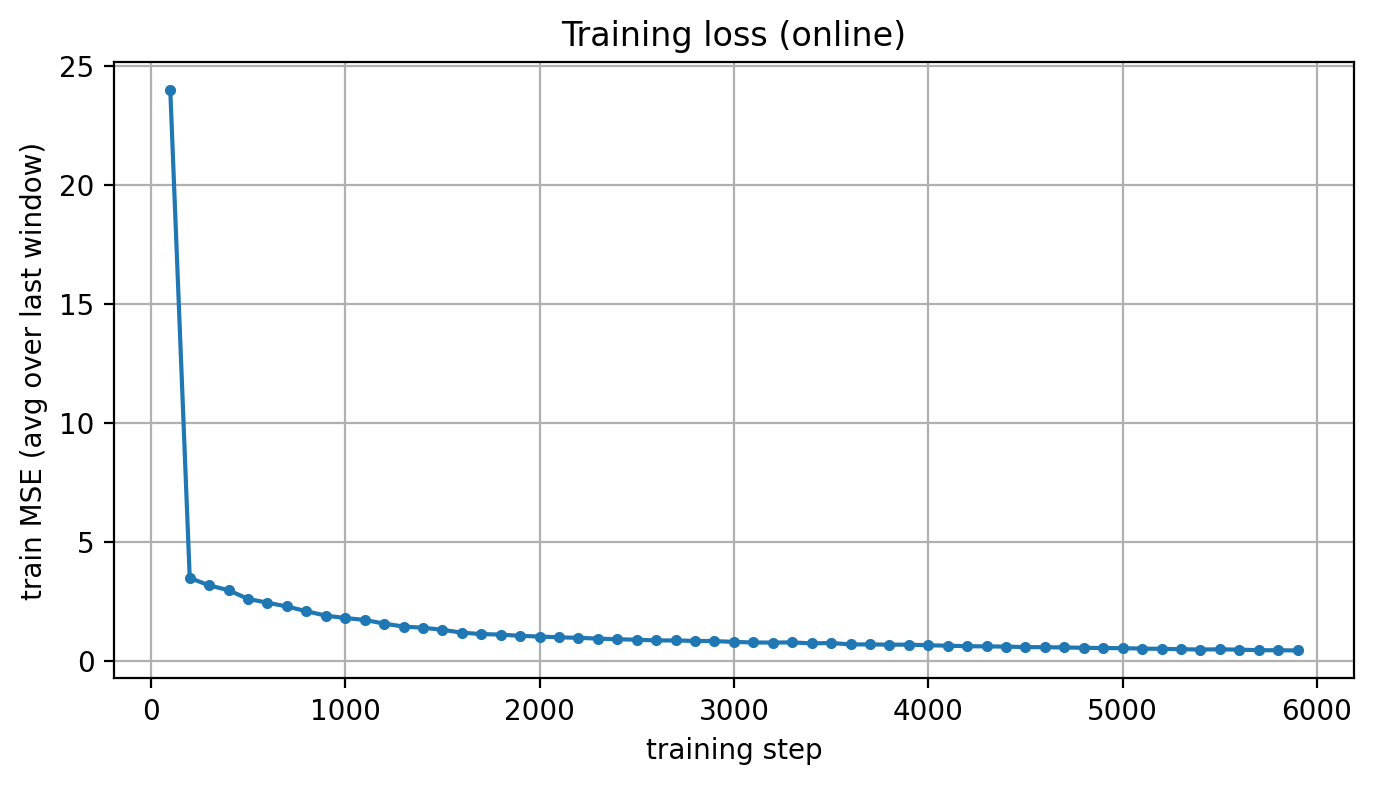

In [ ]:
model = SalaryPredictorA()

model, history = fit_model(
    model,
    data_train,
    data_val,
    lr=1e-3,
    batch_size=128,
    max_epochs=10,
    log_every=100,
    live_plot=True,
    grad_clip=1.0,
)

plot_history(history)


In [ ]:
print('hello')



# Option A


In [19]:
# Option A: CNN
# - parallel conv (kernels 2/3/5)
# - batch norm
# - dropout after conv
# - a slightly deeper head

class ParallelCNNEncoder(nn.Module):
    def __init__(self, emb_layer: nn.Embedding, out_channels=96, kernels=(2,3,5), dropout=0.2):
        super().__init__()
        self.emb = emb_layer
        emb_size = emb_layer.embedding_dim

        self.convs = nn.ModuleList([
            nn.Conv1d(emb_size, out_channels, kernel_size=k, padding=k//2)
            for k in kernels
        ])
        self.bns = nn.ModuleList([nn.BatchNorm1d(out_channels) for _ in kernels])
        self.dropout = nn.Dropout(dropout)

        self.out_dim = out_channels * len(kernels)

    def forward(self, x):  # x: [B, T]
        e = self.emb(x).transpose(1,2)  # [B, E, T]
        parts = []
        for conv, bn in zip(self.convs, self.bns):
            h = conv(e)                  # [B, C, T]
            h = bn(h)
            h = F.relu(h)
            h = self.dropout(h)
            parts.append(torch.max(h, dim=2).values)  # [B, C]
        return torch.cat(parts, dim=1)   # [B, C*len(kernels)]


class SalaryPredictorA(nn.Module):
    def __init__(self, n_tokens=len(tokens), n_cat_features=len(categorical_vectorizer.vocabulary_), hid=128,
                 emb_size=64, cnn_channels=96, dropout=0.3):
        super().__init__()
        self.emb = nn.Embedding(n_tokens, emb_size, padding_idx=PAD_IX)

        # share embeddings between title/desc (also partially fits option C)
        self.title_enc = ParallelCNNEncoder(self.emb, out_channels=cnn_channels, kernels=(2,3,5), dropout=dropout)
        self.desc_enc  = ParallelCNNEncoder(self.emb, out_channels=cnn_channels, kernels=(2,3,5), dropout=dropout)

        self.cat_fc = nn.Sequential(
            nn.Linear(n_cat_features, hid),
            nn.BatchNorm1d(hid),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        feat_dim = self.title_enc.out_dim + self.desc_enc.out_dim + hid

        self.head = nn.Sequential(
            nn.Linear(feat_dim, hid),
            nn.BatchNorm1d(hid),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hid, hid//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hid//2, 1),
        )

    def forward(self, batch):
        title_vec = self.title_enc(batch["Title"])
        desc_vec  = self.desc_enc(batch["FullDescription"])
        cat_vec   = self.cat_fc(batch["Categorical"])

        x = torch.cat([title_vec, desc_vec, cat_vec], dim=1)
        return self.head(x).squeeze(1)




In [ ]:

model_a = SalaryPredictorA()
model_a, hist_a = fit_model(model_a, data_train, data_val,
                           lr=2e-3,
                           batch_size=128, max_epochs=10, grad_clip=1.0)
plot_history(hist_a, "Option A: Parallel CNN + BN + Dropout")
print("Best val MAE (A):", eval_mae(model_a, data_val))

In [ ]:
def plot_history(history, title=""):
    epochs = np.arange(1, len(history["val_mae"]) + 1)
    plt.figure(figsize=(7, 4))
    plt.plot(epochs, history["val_mae"], marker="o")
    plt.xlabel("epoch")
    plt.ylabel("val MAE")
    plt.title(title or "Validation MAE")
    plt.grid(True)
    plt.show()

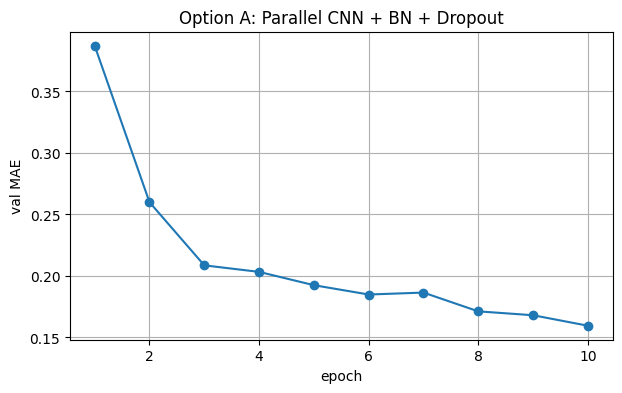

Best val MAE (A): 0.15950314700603485


In [ ]:
plot_history(hist_a, "Option A: Parallel CNN + BN + Dropout")
print("Best val MAE (A):", eval_mae(model_a, data_val))